# 摩擦音モデル — Phase 2: 後方腔フィルタ + 有声摩擦音

Phase 1 では「前方腔フィルタ＋乱流ノイズ」で /s/ /ʃ/ /f/ を合成した。  
Phase 2 では以下の2点を追加し、モデルをより現実に近づける。

### 今回の追加内容

#### 1. 後方腔フィルタ（Back Cavity Filter）

収縮部から声門側の空腔（後方腔）も独自の共鳴を持ち、摩擦音スペクトルに低〜中域の構造を加える。

```
声門 ─────── 後方腔 ──── [収縮] ──── 前方腔 ──── 口
              L_back              L_front
              ↓共鳴                ↓共鳴
         低・中域ピーク         高域ピーク
```

#### 2. 有声摩擦音（Voiced Fricative）

声帯が振動しながら収縮部でも乱流が発生する状態。  
**周期的な声帯音源** と **確率的な乱流ノイズ源** が同時に働く。

```
声帯（周期的）─→ 声道フィルタ ─→ ┐
                                   ├─ mix ─→ 出力
乱流（確率的）─→ 前後腔フィルタ ─→ ┘
```

**参考文献**
- Fant, G. (1970). *Acoustic Theory of Speech Production.* Mouton.
- Fant, G., Liljencrants, J., & Lin, Q. (1985). A four-parameter model of glottal flow. *STL-QPSR*, 4, 1–13. (LF モデル原論文)
- Shadle, C.H. (1985). *The acoustics of fricative consonants.* MIT RLE Tech. Report 506.

## 準備：ライブラリと Phase 1 の関数を再定義

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1e293b', 'axes.facecolor': '#0f172a',
    'axes.edgecolor': '#475569', 'axes.labelcolor': '#cbd5e1',
    'xtick.color': '#94a3b8', 'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0', 'grid.color': '#334155',
    'grid.linestyle': '--', 'grid.alpha': 0.6, 'lines.linewidth': 1.8,
})

# ── 物理定数 ─────────────────────────────────────────────────────
FS      = 44100
C       = 343.0
NU      = 1.5e-5
RE_CRIT = 1800.0

# ── Phase 1 の関数（コンパクト版）───────────────────────────────
def reynolds_number(Q, Ac):
    return (Q / Ac) * (2 * np.sqrt(Ac / np.pi)) / NU

def noise_amplitude(Re, alpha=1.0):
    return np.maximum(0.0, Re - RE_CRIT) ** alpha

def front_cavity_filter(L_front_m, fs=FS):
    nyq = fs / 2.0
    f1  = C / (4 * L_front_m)
    hp_cut = max(200.0, f1 / 3.0)
    sos_hp = signal.butter(3, hp_cut / nyq, btype='high', output='sos')
    low  = max(300.0,       f1 * 0.60)
    high = min(nyq - 200.0, f1 * 1.40)
    sos_bp = signal.butter(2, [low / nyq, high / nyq], btype='band', output='sos')
    return sos_hp, sos_bp, f1

print('準備完了')

準備完了


---
## 1. 後方腔フィルタ

### 理論

後方腔（声門〜収縮部）を片端閉（声門側）・片端開（収縮部側）の気柱と近似すると、  
共鳴周波数は以下で与えられる：

$$
f_n^{\text{back}} = \frac{(2n-1)\,c}{4\,L_{\text{back}}}, \quad n = 1, 2, 3, \ldots
$$

| 音素 | 収縮部位 | $L_{\text{back}}$ | $f_1^{\text{back}}$ | $f_2^{\text{back}}$ |
|------|----------|-------------------|---------------------|---------------------|
| /s/  | 歯茎（前部）    | ≈ 14 cm | ≈ 610 Hz  | ≈ 1840 Hz |
| /ʃ/  | 後部歯茎  | ≈ 11 cm | ≈ 780 Hz  | ≈ 2340 Hz |
| /f/  | 唇歯    | ≈ 17 cm | ≈ 500 Hz  | ≈ 1510 Hz |

後方腔共鳴は **低〜中域（0.5〜3 kHz）** に緩やかなピークを加え、  
前方腔の高域ピークと合わさって実際の摩擦音スペクトルに近づく。

### フォルマント共鳴器の実装

より正確な共鳴フィルタとして、**極（pole）を直接配置する二次共鳴器**を使う：

$$
\text{極} = r\,e^{\pm j\,2\pi f/f_s}, \quad r = e^{-\pi\,B/f_s}
$$

ここで $B$ は帯域幅 [Hz]。$r$ が 1 に近いほど鋭い共鳴になる。

In [2]:
def resonator_sos(f: float, bw: float, fs: int = FS) -> np.ndarray:
    """
    単一共鳴周波数の二次 IIR フィルタ（SOS 形式）を返す。
    極を直接配置する方法で正確な帯域幅を実現する。

    Parameters
    ----------
    f  : 共鳴周波数 [Hz]
    bw : 帯域幅（−3dB 幅）[Hz]
    """
    r     = np.exp(-np.pi * bw / fs)
    theta = 2.0 * np.pi * f / fs
    pole1 = r * np.exp( 1j * theta)
    pole2 = r * np.exp(-1j * theta)
    # ゲイン正規化：直流ゲインを 1 に
    zeros = []
    poles = [pole1, pole2]
    gain  = 1.0
    sos   = signal.zpk2sos(zeros, poles, gain)
    return sos


def back_cavity_filter(L_back_m: float, fs: int = FS, n_resonances: int = 3):
    """
    後方腔フィルタ（声門〜収縮部）の SOS リストを返す。
    共鳴周波数: f_n = (2n-1) * c / (4 * L_back)

    Parameters
    ----------
    L_back_m    : 後方腔長 [m]
    n_resonances: 考慮する共鳴次数
    """
    nyq    = fs / 2.0
    result = []   # (freq, bw, sos)
    for n in range(1, n_resonances + 1):
        fn = (2 * n - 1) * C / (4 * L_back_m)
        if fn >= nyq:
            break
        bw = fn * 0.12   # Q ≈ 8（声道壁の損失を模擬）
        sos = resonator_sos(fn, bw, fs)
        result.append((fn, bw, sos))
    return result


def apply_sos_list(x: np.ndarray, sos_list: list) -> np.ndarray:
    """SOS フィルタのリストを順番に適用する。"""
    for _, _, sos in sos_list:
        x = signal.sosfilt(sos, x)
    return x


# ── 後方腔共鳴の確認 ─────────────────────────────────────────────
print(f"{'音素':<5}  {'L_back':>8}  {'f₁':>8}  {'f₂':>8}  {'f₃':>8}")
print('-' * 48)
for phoneme, L_back in [('/s/', 0.14), ('/ʃ/', 0.11), ('/f/', 0.17)]:
    resonances = back_cavity_filter(L_back)
    freqs = [f'{r[0]:.0f} Hz' for r in resonances]
    print(f"{phoneme:<5}  {L_back*100:>6.1f} cm  {'  '.join(freqs)}")

音素       L_back        f₁        f₂        f₃
------------------------------------------------
/s/      14.0 cm  612 Hz  1837 Hz  3062 Hz
/ʃ/      11.0 cm  780 Hz  2339 Hz  3898 Hz
/f/      17.0 cm  504 Hz  1513 Hz  2522 Hz


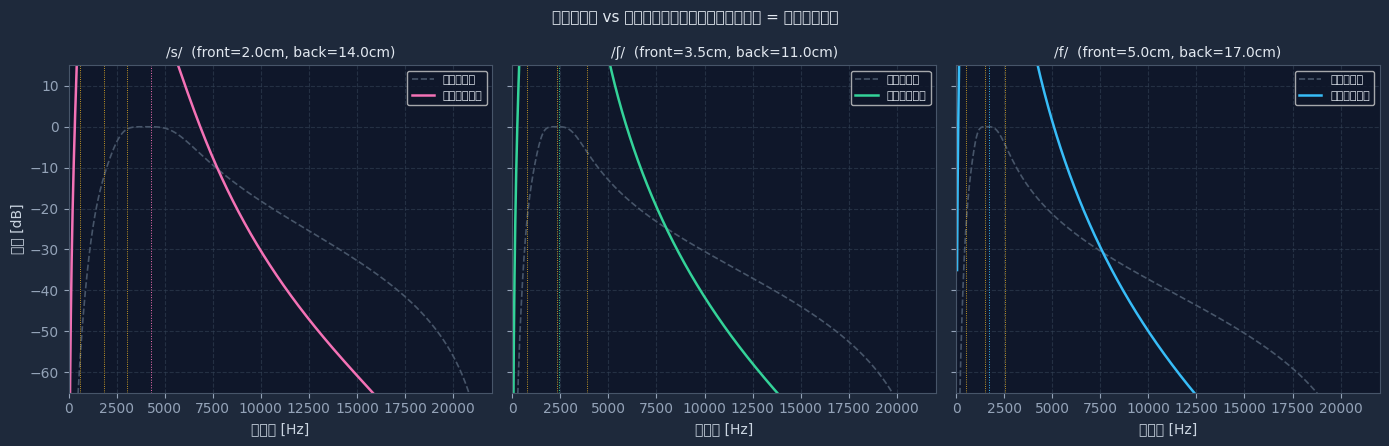

In [3]:
# ── 前方腔のみ vs 前方＋後方腔の周波数特性比較 ─────────────────
fricative_params = {
    '/s/':  {'Ac': 0.15e-4, 'L_front': 0.020, 'L_back': 0.140, 'col': '#f472b6'},
    '/ʃ/':  {'Ac': 0.20e-4, 'L_front': 0.035, 'L_back': 0.110, 'col': '#34d399'},
    '/f/':  {'Ac': 0.30e-4, 'L_front': 0.050, 'L_back': 0.170, 'col': '#38bdf8'},
}

freqs_plot = np.linspace(50, FS / 2, 8192)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (phoneme, p) in zip(axes, fricative_params.items()):
    # 前方腔のみ
    sos_hp, sos_bp, f1_front = front_cavity_filter(p['L_front'])
    _, H_hp = signal.sosfreqz(sos_hp, worN=freqs_plot, fs=FS)
    _, H_bp = signal.sosfreqz(sos_bp, worN=freqs_plot, fs=FS)
    H_front = np.abs(H_hp) * np.abs(H_bp)

    # 後方腔の合成ゲイン
    back_resonances = back_cavity_filter(p['L_back'])
    H_back = np.ones(len(freqs_plot))
    for fn, bw, sos in back_resonances:
        _, H_b = signal.sosfreqz(sos, worN=freqs_plot, fs=FS)
        H_back *= np.abs(H_b)

    H_combined = H_front * H_back

    ax.plot(freqs_plot, 20 * np.log10(H_front    + 1e-10),
            color='#475569', linewidth=1.2, linestyle='--', label='前方腔のみ')
    ax.plot(freqs_plot, 20 * np.log10(H_combined + 1e-10),
            color=p['col'],  linewidth=1.8,               label='前方＋後方腔')

    ax.axvline(f1_front, color=p['col'], linewidth=0.7, linestyle=':')
    for fn, _, _ in back_resonances:
        ax.axvline(fn, color='#fbbf24', linewidth=0.6, linestyle=':')

    ax.set_title(f'{phoneme}  (front={p["L_front"]*100:.1f}cm, back={p["L_back"]*100:.1f}cm)',
                 fontsize=10)
    ax.set_xlabel('周波数 [Hz]')
    ax.set_xlim(0, FS / 2)
    ax.set_ylim(-65, 15)
    ax.legend(fontsize=8)
    ax.grid(True)

axes[0].set_ylabel('振幅 [dB]')
fig.suptitle('前方腔のみ vs 前方＋後方腔フィルタ（黄色点線 = 後方腔共鳴）', fontsize=11)
plt.tight_layout()
plt.show()

---
## 2. 声帯音源モデル（有声成分）

有声摩擦音には声帯振動による周期的成分が含まれる。  
ここでは **LF モデルを簡略化した非対称三角グロタルパルス** を実装する。

### パルス形状

1 周期 $T_0 = 1/f_0$ を 3 フェーズに分割する：

| フェーズ | 区間 | 波形 |
|---|---|---|
| 開口（Opening） | $0 \sim T_p$（= 40% $T_0$）| $t^2$ の放物線（ゆっくり開く）|
| 閉口（Closing） | $T_p \sim T_p + T_n$（= 30% $T_0$）| 線形下降（急に閉まる）|
| 閉鎖（Closed）  | $T_p + T_n \sim T_0$ | ゼロ（声帯が完全閉鎖）|

この非対称性が人間の声帯振動の特徴で、有声音の「豊かさ」を作り出す。

最後に **口唇放射（radiation）** を模擬する一次微分フィルタ $y[n] = x[n] - x[n-1]$ を適用する。  
（これにより 6 dB/oct の高域強調がかかり、音源が自然に聞こえる）

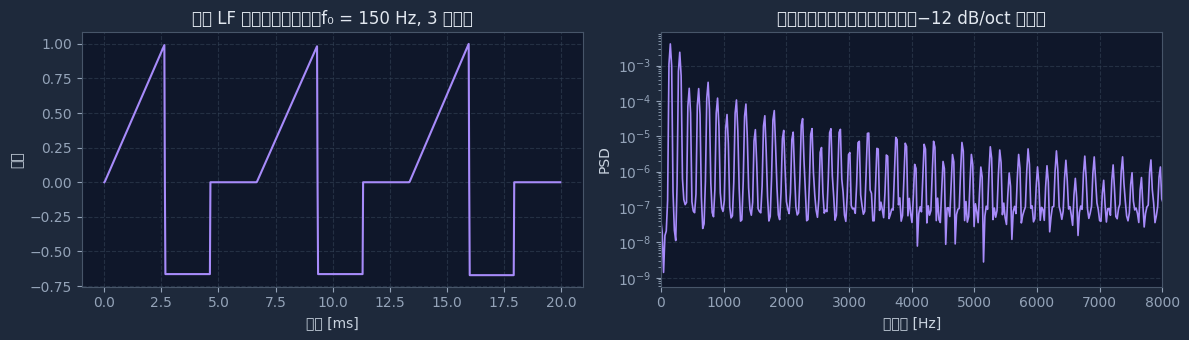

声帯音源（f₀=150Hz）:


In [4]:
def glottal_pulse_shape(T0: int) -> np.ndarray:
    """
    1 周期分の簡略 LF グロタルパルス波形を返す（長さ T0 の配列）。
    最大値が 1 になるよう正規化する。
    """
    Tp = int(0.40 * T0)   # 開口フェーズ長
    Tn = int(0.30 * T0)   # 閉口フェーズ長

    pulse = np.zeros(T0)

    # 開口：0 → 1 の放物線上昇
    t_open  = np.linspace(0, 1, Tp)
    pulse[:Tp] = t_open ** 2

    # 閉口：1 → 0 の線形下降
    pulse[Tp:Tp + Tn] = np.linspace(1.0, 0.0, Tn)

    # 残り（閉鎖フェーズ）はゼロのまま
    return pulse


def generate_voiced_source(
    duration: float,
    f0: float = 120.0,
    fs: int   = FS,
    jitter: float = 0.005,   # ピッチの微小揺らぎ（自然な声に近づける）
) -> np.ndarray:
    """
    簡略 LF グロタルパルス列を生成し、口唇放射フィルタを適用して返す。

    Parameters
    ----------
    jitter : 各周期に加えるピッチ揺らぎの相対量（0 = 完全周期的）
    """
    N    = int(duration * fs)
    T0   = int(fs / f0)         # 基本周期（サンプル数）
    base_pulse = glottal_pulse_shape(T0)

    output = np.zeros(N)
    pos    = 0
    rng    = np.random.default_rng(1)

    while pos < N:
        # ジッタ付き周期
        T_cur = int(T0 * (1 + rng.uniform(-jitter, jitter)))
        T_cur = max(int(fs / 400), min(int(fs / 50), T_cur))   # 50〜400 Hz の範囲に制限
        pulse = glottal_pulse_shape(T_cur)

        end = min(pos + T_cur, N)
        output[pos:end] += pulse[:end - pos]
        pos += T_cur

    # 口唇放射：一次差分（6 dB/oct 高域強調）
    output = np.diff(output, prepend=output[0])

    # 正規化
    peak = np.max(np.abs(output))
    if peak > 1e-10:
        output /= peak

    return output.astype(np.float32)


# ── 声帯音源の波形確認 ───────────────────────────────────────────
voiced_demo = generate_voiced_source(0.08, f0=150.0)
T0_demo = int(FS / 150.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# 波形（3 周期分）
t_demo = np.arange(3 * T0_demo) / FS * 1000   # ms
axes[0].plot(t_demo, voiced_demo[:3 * T0_demo], color='#a78bfa', linewidth=1.5)
axes[0].set_xlabel('時間 [ms]')
axes[0].set_ylabel('振幅')
axes[0].set_title('簡略 LF グロタルパルス（f₀ = 150 Hz, 3 周期）')
axes[0].grid(True)

# スペクトル
f_spec, P = signal.welch(voiced_demo, fs=FS, nperseg=2048)
axes[1].semilogy(f_spec, P, color='#a78bfa', linewidth=1.2)
axes[1].set_xlabel('周波数 [Hz]')
axes[1].set_ylabel('PSD')
axes[1].set_title('グロタルパルスのスペクトル（−12 dB/oct 傾き）')
axes[1].set_xlim(0, 8000)
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('声帯音源（f₀=150Hz）:')
display(Audio(generate_voiced_source(1.5, f0=150.0), rate=FS))

---
## 3. 声道フォルマントフィルタ

有声成分は声帯音源が**全声道**を通過したものである。  
有声摩擦音の文脈では、おおよそ中立母音（シュワー）に近いフォルマントになることが多い。

| 音素 | F1 | F2 | F3 | 備考 |
|------|-----|-----|-----|------|
| /z/  | 350 Hz | 1800 Hz | 2600 Hz | /s/ の有声版：歯茎で収縮 |
| /v/  | 400 Hz | 1000 Hz | 2200 Hz | /f/ の有声版：唇歯で収縮 |
| 中立 | 500 Hz | 1500 Hz | 2500 Hz | 参考（シュワー）|

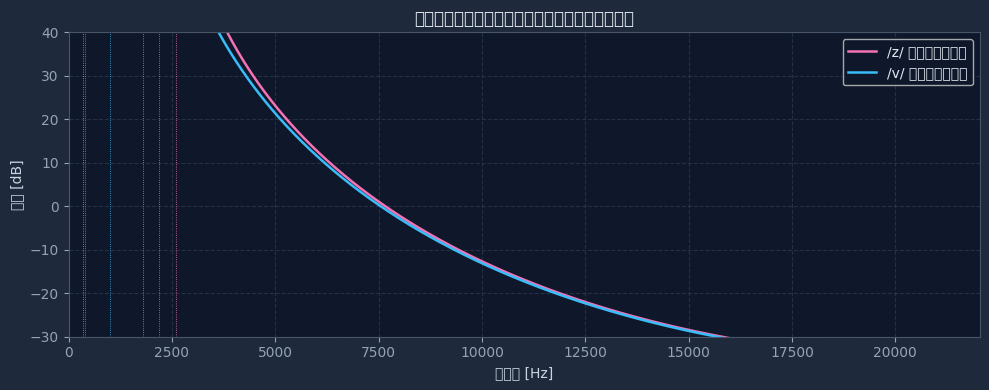

In [5]:
def vocal_tract_filter(formants: list[tuple[float, float]], fs: int = FS) -> list[np.ndarray]:
    """
    フォルマントのリストから声道フィルタ（SOS リスト）を生成する。
    各フォルマントを独立した二次共鳴器で近似する（all-pole モデル）。

    Parameters
    ----------
    formants : [(freq_Hz, bandwidth_Hz), ...]
    """
    nyq = fs / 2.0
    sos_list = []
    for f, bw in formants:
        if 10 < f < nyq:
            sos_list.append(resonator_sos(f, bw, fs))
    return sos_list


# ── フォルマントフィルタの周波数特性を確認 ────────────────────
formants_z = [(350, 80), (1800, 120), (2600, 180)]   # /z/
formants_v = [(400, 90), (1000, 130), (2200, 170)]   # /v/

fig, ax = plt.subplots(figsize=(10, 4))
freqs_plt = np.linspace(50, FS / 2, 8192)

for formants, phoneme, col in [
        (formants_z, '/z/ の声道フィルタ', '#f472b6'),
        (formants_v, '/v/ の声道フィルタ', '#38bdf8')]:
    sos_list = vocal_tract_filter(formants)
    H_total  = np.ones(len(freqs_plt))
    for sos in sos_list:
        _, H = signal.sosfreqz(sos, worN=freqs_plt, fs=FS)
        H_total *= np.abs(H)
    ax.plot(freqs_plt, 20 * np.log10(H_total + 1e-10), color=col, label=phoneme)
    for f, _ in formants:
        ax.axvline(f, color=col, linewidth=0.6, linestyle=':')

ax.set_xlabel('周波数 [Hz]')
ax.set_ylabel('振幅 [dB]')
ax.set_title('有声摩擦音の声道フィルタ（フォルマント共鳴）')
ax.set_xlim(0, FS / 2)
ax.set_ylim(-30, 40)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 4. 有声摩擦音の合成

2 つの音源を混合する。`voiced_ratio` は有声成分の割合（0.0 = 完全無声、1.0 = 純粋有声）。

実際の有声摩擦音では `voiced_ratio ≈ 0.2〜0.4` が自然に聞こえる  
（低域は声帯振動、高域は乱流ノイズが支配的）。

In [6]:
def generate_fricative_full(
    Ac_cm2:      float = 0.15,
    L_front_cm:  float = 2.0,
    L_back_cm:   float = 14.0,
    Q_ccps:      float = 200.0,
    voiced_ratio: float = 0.0,       # 0 = 無声、0.3 程度 = 有声摩擦音
    f0:          float = 120.0,      # 有声時の基本周波数
    formants:    list  = None,       # 有声成分の声道フォルマント
    duration:    float = 1.5,
    gain:        float = 0.6,
    fs:          int   = FS,
    seed:        int | None = 42,
) -> tuple[np.ndarray, dict]:
    """
    前後腔フィルタを持つ摩擦音（無声 / 有声）を合成する。

    無声成分：白色ノイズ → 前方腔フィルタ → 後方腔フィルタ
    有声成分：LF パルス → 声道フォルマントフィルタ → 口唇放射（generate_voiced_source 内）
    """
    if formants is None:
        formants = [(500, 100), (1500, 150), (2500, 200)]

    rng = np.random.default_rng(seed)
    N   = int(duration * fs)

    # 単位変換
    Q       = Q_ccps * 1e-6
    Ac      = Ac_cm2    * 1e-4
    L_front = L_front_cm * 1e-2
    L_back  = L_back_cm  * 1e-2

    # ── 無声（摩擦ノイズ）成分 ─────────────────────────────────
    Re      = reynolds_number(Q, Ac)
    amp     = noise_amplitude(Re)
    REF_AMP = 5000.0

    noise = rng.standard_normal(N).astype(np.float64)

    # 前方腔フィルタ
    sos_hp, sos_bp, f1_front = front_cavity_filter(L_front, fs)
    noise = signal.sosfilt(sos_hp, noise)
    noise = signal.sosfilt(sos_bp, noise)

    # 後方腔フィルタ（各共鳴器を順次適用）
    back_res = back_cavity_filter(L_back, fs)
    noise    = apply_sos_list(noise, back_res)

    # フェードイン / フェードアウト
    fade = int(0.02 * fs)
    env  = np.ones(N)
    env[:fade]  = np.linspace(0, 1, fade)
    env[-fade:] = np.linspace(1, 0, fade)
    noise *= env

    # 正規化
    peak = np.max(np.abs(noise))
    if peak > 1e-10:
        noise /= peak

    noise_scaled = noise * gain * (1 - voiced_ratio) * min(1.0, amp / REF_AMP)

    # ── 有声成分 ────────────────────────────────────────────────
    if voiced_ratio > 0.0:
        voiced_raw = generate_voiced_source(duration, f0=f0, fs=fs)

        # 声道フォルマントフィルタ
        vt_sos = vocal_tract_filter(formants, fs)
        voiced = voiced_raw.astype(np.float64)
        for sos in vt_sos:
            voiced = signal.sosfilt(sos, voiced)

        # 正規化
        peak_v = np.max(np.abs(voiced))
        if peak_v > 1e-10:
            voiced /= peak_v

        voiced_scaled = voiced * gain * voiced_ratio
    else:
        voiced_scaled = np.zeros(N)

    wav = (noise_scaled + voiced_scaled).astype(np.float32)
    wav = np.clip(wav, -0.95, 0.95)

    info = {
        'Re': Re, 'sigma': amp, 'f1_front': f1_front,
        'back_resonances': [r[0] for r in back_res],
        'voiced_ratio': voiced_ratio,
    }
    return wav, info

print('generate_fricative_full() 定義完了')

generate_fricative_full() 定義完了


In [7]:
# ── /z/（有声歯茎摩擦音）の合成 ────────────────────────────────
wav_z, info_z = generate_fricative_full(
    Ac_cm2=0.15, L_front_cm=2.0, L_back_cm=14.0,
    voiced_ratio=0.30, f0=130.0,
    formants=formants_z,
)
print(f"/z/  Re={info_z['Re']:.0f}  σ={info_z['sigma']:.0f}  "
      f"front共鳴={info_z['f1_front']:.0f}Hz  "
      f"back共鳴={[f'{f:.0f}' for f in info_z['back_resonances']]}Hz")
display(Audio(wav_z, rate=FS))

/z/  Re=3885  σ=2085  front共鳴=4288Hz  back共鳴=['612', '1837', '3062']Hz


In [8]:
# ── /v/（有声唇歯摩擦音）の合成 ────────────────────────────────
wav_v, info_v = generate_fricative_full(
    Ac_cm2=0.30, L_front_cm=5.0, L_back_cm=17.0,
    voiced_ratio=0.35, f0=130.0,
    formants=formants_v,
)
print(f"/v/  Re={info_v['Re']:.0f}  σ={info_v['sigma']:.0f}  "
      f"front共鳴={info_v['f1_front']:.0f}Hz  "
      f"back共鳴={[f'{f:.0f}' for f in info_v['back_resonances']]}Hz")
display(Audio(wav_v, rate=FS))

/v/  Re=2747  σ=947  front共鳴=1715Hz  back共鳴=['504', '1513', '2522']Hz


---
## 5. 無声 / 有声ペアの比較

/s/ vs /z/、/f/ vs /v/ を並べてスペクトログラムと波形で比較する。

**期待される観察ポイント：**
- 有声版は低域（F0 の倍音）にエネルギーが現れる
- 高域のノイズ部分は無声版・有声版でほぼ同形
- 波形に周期的な揺らぎが見える（ピッチ周期）

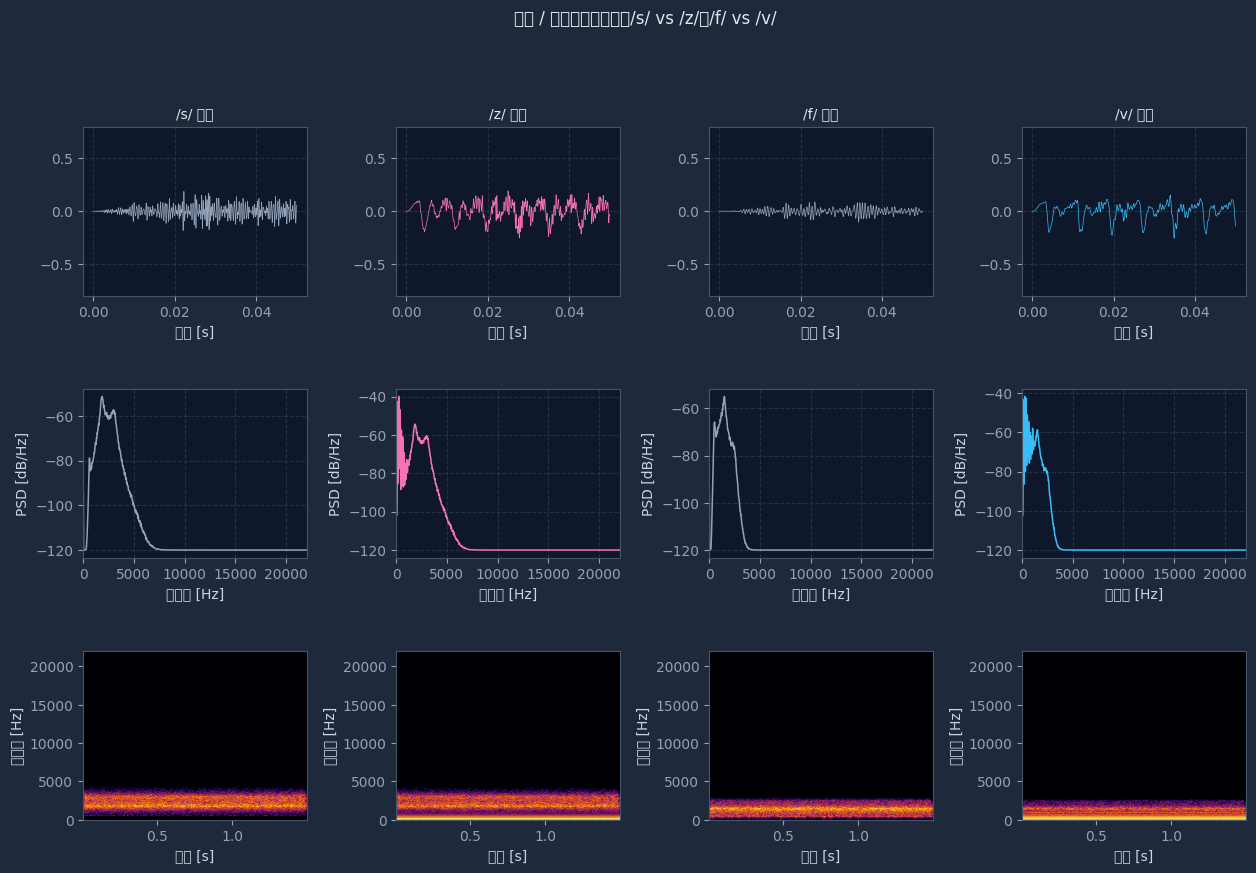

画像を data/processed/analysis/voiced_voiceless_comparison.png に保存しました


In [9]:
# 無声版も前後腔フィルタありで再生成（Phase 1 より精度向上）
wav_s_v2, _ = generate_fricative_full(Ac_cm2=0.15, L_front_cm=2.0, L_back_cm=14.0, voiced_ratio=0.0)
wav_f_v2, _ = generate_fricative_full(Ac_cm2=0.30, L_front_cm=5.0, L_back_cm=17.0, voiced_ratio=0.0)

pairs = [
    ('/s/ 無声', wav_s_v2, '#94a3b8'),
    ('/z/ 有声', wav_z,    '#f472b6'),
    ('/f/ 無声', wav_f_v2, '#94a3b8'),
    ('/v/ 有声', wav_v,    '#38bdf8'),
]

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.40)

for col_i, (label, wav, col) in enumerate(pairs):
    t = np.arange(len(wav)) / FS

    # 波形
    ax_w = fig.add_subplot(gs[0, col_i])
    ax_w.plot(t[:int(0.05 * FS)], wav[:int(0.05 * FS)], color=col, linewidth=0.5)
    ax_w.set_title(label, fontsize=10)
    ax_w.set_xlabel('時間 [s]')
    ax_w.set_ylim(-0.8, 0.8)
    ax_w.grid(True)

    # PSD
    ax_p = fig.add_subplot(gs[1, col_i])
    f_w, P = signal.welch(wav, fs=FS, nperseg=2048)
    ax_p.plot(f_w, 10 * np.log10(P + 1e-12), color=col, linewidth=1.1)
    ax_p.set_xlabel('周波数 [Hz]')
    ax_p.set_ylabel('PSD [dB/Hz]')
    ax_p.set_xlim(0, FS / 2)
    ax_p.grid(True)

    # スペクトログラム
    ax_s = fig.add_subplot(gs[2, col_i])
    f_sg, t_sg, Sxx = signal.spectrogram(wav, fs=FS, nperseg=512, noverlap=480)
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    ax_s.pcolormesh(t_sg, f_sg, Sxx_db, shading='gouraud', cmap='inferno',
                    vmin=Sxx_db.max() - 50, vmax=Sxx_db.max())
    ax_s.set_xlabel('時間 [s]')
    ax_s.set_ylabel('周波数 [Hz]')
    ax_s.set_ylim(0, FS / 2)

fig.suptitle('無声 / 有声ペアの比較：/s/ vs /z/、/f/ vs /v/', fontsize=12, y=1.01)
plt.savefig('../data/processed/analysis/voiced_voiceless_comparison.png',
            dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('画像を data/processed/analysis/voiced_voiceless_comparison.png に保存しました')

---
## 6. voiced_ratio の影響：無声 → 有声の連続変化

`voiced_ratio` を 0.0 → 0.5 に変化させて音の変わり方を試聴する。  
実際の発話では /s/ → /z/ の変化がこれに相当する。

In [10]:
print('/s/ ← voiced_ratio 変化 → /z/  (Ac=0.15cm², L_front=2cm)\n')

for vr in [0.0, 0.15, 0.30, 0.45]:
    wav_vr, _ = generate_fricative_full(
        Ac_cm2=0.15, L_front_cm=2.0, L_back_cm=14.0,
        voiced_ratio=vr, f0=130.0, formants=formants_z, seed=7,
    )
    label = '無声 /s/' if vr == 0.0 else f'voiced_ratio = {vr:.2f}'
    print(f'{label}:')
    display(Audio(wav_vr, rate=FS))

/s/ ← voiced_ratio 変化 → /z/  (Ac=0.15cm², L_front=2cm)

無声 /s/:


voiced_ratio = 0.15:


voiced_ratio = 0.30:


voiced_ratio = 0.45:


---
## まとめと次のステップ

### Phase 2 で追加・確認できたこと

| 追加内容 | 効果 |
|---|---|
| **後方腔フィルタ**（極配置型共鳴器） | 1〜3 kHz に緩やかなピークが加わり、スペクトルがより自然に |
| **LF 簡略グロタルパルス** | 非対称三角波 + 口唇放射で自然な有声音色 |
| **有声摩擦音の混合** | voiced_ratio で無声↔有声を連続的に制御可能 |
| **声道フォルマントフィルタ** | 有声成分の母音的色彩（/z/ は /i/ 寄り、/v/ は円唇） |

### 現モデルの限界と Phase 3 に向けた課題

1. **収縮部位の時間変化（コアーティキュレーション）**  
   /sa/、/za/ のように摩擦音 → 母音へ遷移するには、声道形状を時変させる必要がある。  
   → Phase 3：声道形状配列の時間補間 + 摩擦/母音ソースの自動切替

2. **摩擦音の収縮位置の自動検出**  
   現在は `L_front`・`L_back` を手動で指定している。  
   → 第3プロトタイプの断面積配列から最小断面積セクションを自動検出し Re を計算する。

3. **ノイズ音源の双極子モデル化**  
   Shadle の詳細モデルでは、障害物（歯・唇）近傍で双極子ノイズが発生する。  
   → 音源位置を 2 点に分けて位相差を持たせる（より高次のモデル）。

4. **破擦音（/ts/, /dz/）**  
   閉鎖（無音）→ 摩擦（有声/無声）の遷移を加えれば /ts/ /dz/ が合成できる。